KARMIC SEED - PRICING STRATEGY ANALYSIS

[1/6] Loading datasets...
✓ Loaded 50 SKUs
✓ Loaded 4243 historical sales records
✓ Loaded 12777 ad performance records

[2/6] Cleaning data...
✓ Data cleaning complete

[3/6] Calculating key metrics...
✓ Key metrics calculated

[4/6] Applying pricing strategy framework...
✓ Pricing recommendations generated

[5/6] Generating insights...

KEY INSIGHTS

📊 OVERALL STATISTICS:
  • Total SKUs analyzed: 50
  • Average current price: $30.10
  • Average recommended price: $36.11
  • Average price change: 24.6%
  • SKUs needing price increase: 48
  • SKUs needing price decrease: 2

💰 MARGIN ANALYSIS:
  • Current avg margin: 12.2%
  • Recommended avg margin: 28.5%
  • SKUs below min margin: 42

📦 BY PRODUCT ROLE:
              SKU  Price_Change_Pct  Current_Margin  New_Margin
Product Role                                                   
Core           46             20.95            0.13        0.28
Seasonal        4             66.58           -0.00  

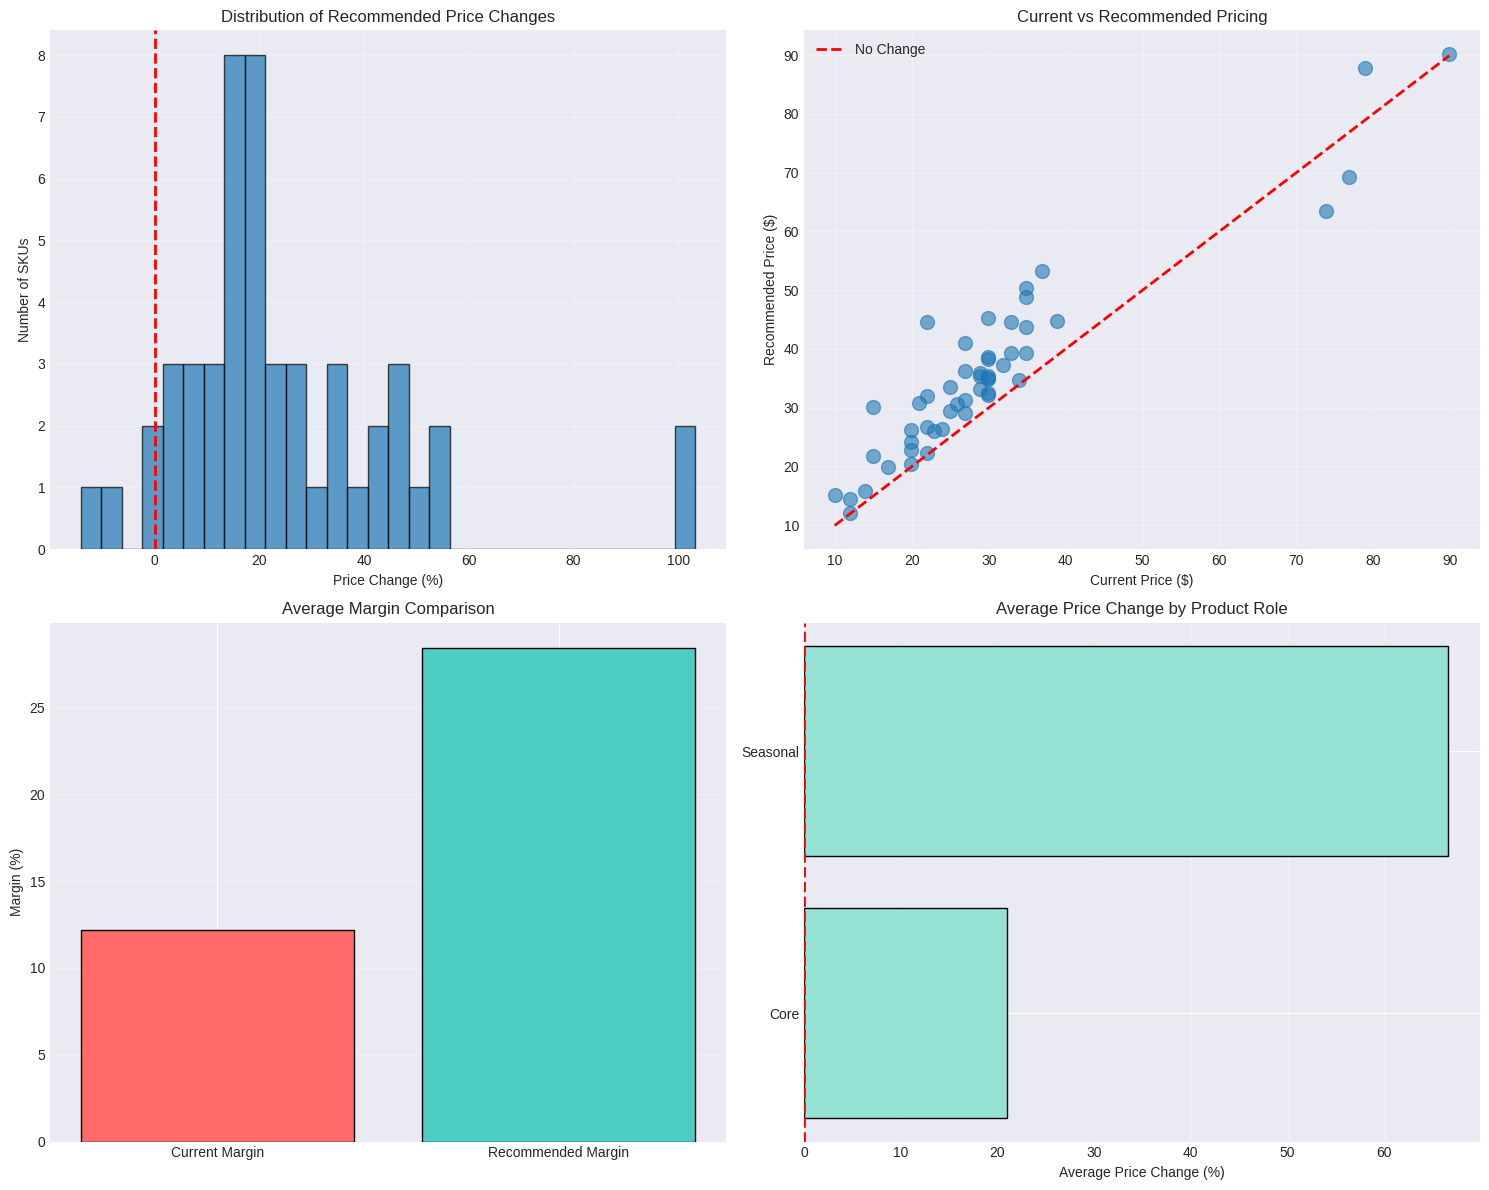

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')

print("="*80)
print("KARMIC SEED - PRICING STRATEGY ANALYSIS")
print("="*80)

# ============================================================================
# SECTION 1: DATA LOADING AND CLEANING
# ============================================================================

print("\n[1/6] Loading datasets...")

# Load all datasets
pricing_df = pd.read_csv('/content/Pricing_Data.csv')
competitor_df = pd.read_csv('/content/Competitor_Data.csv')
sales_df = pd.read_csv('/content/Historical_Sales.csv')
returns_df = pd.read_csv('/content/Returns_Data.csv')
inventory_df = pd.read_csv('/content/Inventory_Health.csv')
ads_df = pd.read_csv('/content/Ads_Performance.csv')

print(f"✓ Loaded {len(pricing_df)} SKUs")
print(f"✓ Loaded {len(sales_df)} historical sales records")
print(f"✓ Loaded {len(ads_df)} ad performance records")

# ============================================================================
# SECTION 2: DATA CLEANING FUNCTIONS
# ============================================================================

def clean_currency(value):
    """Remove currency symbols and convert to float"""
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float)):
        return float(value)
    # Remove $, ₹, commas, and spaces
    cleaned = str(value).replace('$', '').replace('₹', '').replace(',', '').replace(' ', '').strip()
    try:
        return float(cleaned)
    except:
        return np.nan

def clean_percentage(value):
    """Convert percentage string to decimal"""
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float)):
        return float(value) / 100 if value > 1 else float(value)
    cleaned = str(value).replace('%', '').strip()
    try:
        val = float(cleaned)
        return val / 100 if val > 1 else val
    except:
        return np.nan

print("\n[2/6] Cleaning data...")

# Clean Pricing Data
pricing_df['FBA_Fee'] = pricing_df['FBA Fee'].apply(clean_currency)
pricing_df['Storage_Fee'] = pricing_df['Storage Fee'].apply(clean_currency)
pricing_df['Handling_Cost'] = pricing_df['Handling_Cost'].apply(clean_currency)
pricing_df['Cost'] = pricing_df['Cost'].apply(clean_currency)
pricing_df['Current_Price'] = pricing_df['Current_Price'].apply(clean_currency)
pricing_df['Min_Margin'] = pricing_df['Minimum_Acceptable_Margin_%'].apply(clean_percentage)
pricing_df['Target_Margin'] = pricing_df['Target_Gross_Margin_%'].apply(clean_percentage)

# Calculate total cost per unit
pricing_df['Total_Cost'] = (
    pricing_df['Cost'] +
    pricing_df['FBA_Fee'].fillna(0) +
    pricing_df['Storage_Fee'].fillna(0) +
    pricing_df['Handling_Cost'].fillna(0)
)

# Clean Competitor Data
competitor_df['Avg_Competitor_Price'] = competitor_df['Avg_Competitor_Price'].apply(clean_currency)
competitor_df['Lowest_Competitor_Price'] = competitor_df['Lowest_Competitor_Price'].apply(clean_currency)
competitor_df['Highest_Competitor_Price'] = competitor_df['Highest_Competitor_Price'].apply(clean_currency)

# Clean Returns Data
returns_df['Return_7d'] = returns_df['Return Quantity \n(Last 7 days)'].apply(lambda x: clean_currency(x) if pd.notna(x) else 0)
returns_df['Return_30d'] = returns_df['Return Quantity \n(Last 30 days)'].fillna(0)
returns_df['Return_60d'] = returns_df['Return Quantity \n(Last 60 days)'].fillna(0)
returns_df['Return_90d'] = returns_df['Return Quantity \n(Last 90 days)'].fillna(0)

# Clean Sales Data - convert date (handle multiple formats and errors)
sales_df['Date'] = pd.to_datetime(sales_df['Date'], format='mixed', dayfirst=False, errors='coerce')
# Remove rows with invalid dates
sales_df = sales_df.dropna(subset=['Date'])
sales_df = sales_df.sort_values('Date')

# Clean Ads Data (handle multiple formats and errors)
ads_df['date'] = pd.to_datetime(ads_df['date'], format='mixed', dayfirst=False, errors='coerce')
# Remove rows with invalid dates
ads_df = ads_df.dropna(subset=['date'])
ads_df = ads_df.sort_values('date')

print("✓ Data cleaning complete")

# ============================================================================
# SECTION 3: CALCULATE KEY METRICS PER SKU
# ============================================================================

print("\n[3/6] Calculating key metrics...")

# Initialize metrics dataframe
metrics = pricing_df[['SKU', 'Product_description', 'Product Role', 'Current_Price', 'Total_Cost', 'Min_Margin', 'Target_Margin']].copy()

# --- SALES METRICS ---
# Aggregate last 30 days and last 90 days
latest_date = sales_df['Date'].max()
date_30d = latest_date - timedelta(days=30)
date_90d = latest_date - timedelta(days=90)

sales_30d = sales_df[sales_df['Date'] >= date_30d].groupby('SKU').agg({
    'Sessions - Total': 'sum',
    'Page Views - Total': 'sum',
    'Units Ordered': 'sum',
    'Ordered Product Sales': 'sum'
}).reset_index()
sales_30d.columns = ['SKU', 'Sessions_30d', 'PageViews_30d', 'Units_30d', 'Revenue_30d']

sales_90d = sales_df[sales_df['Date'] >= date_90d].groupby('SKU').agg({
    'Units Ordered': 'sum',
    'Ordered Product Sales': 'sum'
}).reset_index()
sales_90d.columns = ['SKU', 'Units_90d', 'Revenue_90d']

# Calculate conversion rate
sales_30d['Conversion_Rate'] = sales_30d['Units_30d'] / sales_30d['Sessions_30d']
sales_30d['Conversion_Rate'] = sales_30d['Conversion_Rate'].fillna(0)

# --- AD PERFORMANCE METRICS ---
ads_recent = ads_df[ads_df['date'] >= date_30d].groupby('SKU').agg({
    'impressions': 'sum',
    'clicks': 'sum',
    'spend': 'sum',
    'sales30d': 'sum',
    'acosClicks14d': 'mean',
    'roasClicks14d': 'mean'
}).reset_index()
ads_recent.columns = ['SKU', 'Ad_Impressions', 'Ad_Clicks', 'Ad_Spend_30d', 'Ad_Sales_30d', 'Avg_ACOS', 'Avg_ROAS']

# Calculate ad dependency ratio
ads_recent['Ad_Dependency'] = ads_recent['Ad_Sales_30d'] / (sales_30d.set_index('SKU')['Revenue_30d'].reindex(ads_recent['SKU']).values + 1)
ads_recent['Ad_Dependency'] = ads_recent['Ad_Dependency'].fillna(0).clip(0, 1)

# --- INVENTORY METRICS ---
inventory_metrics = inventory_df[['SKU', 'available', 'sell-through', 'days-of-supply', 'weeks-of-cover-t30', 'units-shipped-t30', 'units-shipped-t90']].copy()

# --- RETURN RATE ---
returns_metrics = returns_df[['SKU', 'Return_30d', 'Return_90d']].copy()

# Calculate return rate
returns_metrics = returns_metrics.merge(sales_30d[['SKU', 'Units_30d']], on='SKU', how='left')
returns_metrics = returns_metrics.merge(sales_90d[['SKU', 'Units_90d']], on='SKU', how='left')
returns_metrics['Return_Rate_30d'] = returns_metrics['Return_30d'] / (returns_metrics['Units_30d'] + 1)
returns_metrics['Return_Rate_90d'] = returns_metrics['Return_90d'] / (returns_metrics['Units_90d'] + 1)
returns_metrics['Return_Rate_30d'] = returns_metrics['Return_Rate_30d'].fillna(0).clip(0, 1)

# --- MERGE ALL METRICS ---
metrics = metrics.merge(competitor_df[['SKU', 'Avg_Competitor_Price', 'Lowest_Competitor_Price', 'Highest_Competitor_Price', 'Competitor_Count']], on='SKU', how='left')
metrics = metrics.merge(sales_30d[['SKU', 'Sessions_30d', 'Units_30d', 'Revenue_30d', 'Conversion_Rate']], on='SKU', how='left')
metrics = metrics.merge(sales_90d[['SKU', 'Units_90d', 'Revenue_90d']], on='SKU', how='left')
metrics = metrics.merge(ads_recent[['SKU', 'Ad_Spend_30d', 'Ad_Sales_30d', 'Avg_ACOS', 'Avg_ROAS', 'Ad_Dependency']], on='SKU', how='left')
metrics = metrics.merge(inventory_metrics, on='SKU', how='left')
metrics = metrics.merge(returns_metrics[['SKU', 'Return_Rate_30d']], on='SKU', how='left')

# Fill missing values
metrics = metrics.fillna({
    'Units_30d': 0,
    'Units_90d': 0,
    'Revenue_30d': 0,
    'Revenue_90d': 0,
    'Conversion_Rate': 0,
    'Ad_Spend_30d': 0,
    'Ad_Dependency': 0,
    'Return_Rate_30d': 0,
    'available': 0,
    'sell-through': 0,
    'days-of-supply': 0,
    'Avg_Competitor_Price': metrics['Current_Price']
})

# Calculate velocity trend (30d vs 90d daily average)
metrics['Velocity_Trend'] = (metrics['Units_30d'] / 30) / ((metrics['Units_90d'] / 90) + 0.1)
metrics['Velocity_Trend'] = metrics['Velocity_Trend'].fillna(1)

# Calculate current margin
metrics['Current_Margin'] = (metrics['Current_Price'] - metrics['Total_Cost']) / metrics['Current_Price']
metrics['Current_Margin'] = metrics['Current_Margin'].fillna(0)

# Competitive position
metrics['Price_vs_Comp'] = metrics['Current_Price'] / metrics['Avg_Competitor_Price']
metrics['Price_vs_Comp'] = metrics['Price_vs_Comp'].fillna(1)

print("✓ Key metrics calculated")

# ============================================================================
# SECTION 4: PRICING STRATEGY FRAMEWORK
# ============================================================================

print("\n[4/6] Applying pricing strategy framework...")

def calculate_recommended_price(row):
    """
    Multi-factor pricing algorithm

    Base Price: Cost + Target Margin

    Adjustments:
    1. Inventory Pressure (-15% to +10%)
    2. Competitive Positioning (-10% to +5%)
    3. Velocity Trend (-10% to +10%)
    4. Ad Efficiency (-5% to +5%)
    5. Return Rate (-5% to 0%)
    """

    # Base price from target margin
    target_price = row['Total_Cost'] / (1 - row['Target_Margin'])

    adjustment_factors = []

    # 1. INVENTORY ADJUSTMENT
    days_supply = row['days-of-supply']
    if days_supply > 90:  # Overstocked
        inv_adj = -0.15
    elif days_supply > 60:
        inv_adj = -0.10
    elif days_supply > 45:
        inv_adj = -0.05
    elif days_supply < 15:  # Understocked
        inv_adj = 0.10
    elif days_supply < 30:
        inv_adj = 0.05
    else:
        inv_adj = 0.00
    adjustment_factors.append(('Inventory', inv_adj))

    # 2. COMPETITIVE POSITIONING
    price_vs_comp = row['Price_vs_Comp']
    if price_vs_comp > 1.20:  # 20% above market
        comp_adj = -0.10
    elif price_vs_comp > 1.10:
        comp_adj = -0.05
    elif price_vs_comp < 0.85:  # Below market - room to raise
        comp_adj = 0.05
    elif price_vs_comp < 0.90:
        comp_adj = 0.03
    else:
        comp_adj = 0.00
    adjustment_factors.append(('Competitive', comp_adj))

    # 3. VELOCITY TREND
    velocity = row['Velocity_Trend']
    if velocity < 0.7:  # Declining sales
        vel_adj = -0.10
    elif velocity < 0.85:
        vel_adj = -0.05
    elif velocity > 1.3:  # Growing sales
        vel_adj = 0.10
    elif velocity > 1.15:
        vel_adj = 0.05
    else:
        vel_adj = 0.00
    adjustment_factors.append(('Velocity', vel_adj))

    # 4. AD EFFICIENCY
    ad_dependency = row['Ad_Dependency']
    avg_acos = row['Avg_ACOS']
    if ad_dependency > 0.5 and avg_acos > 0.35:  # High ad dependency + poor ACOS
        ad_adj = -0.05
    elif ad_dependency > 0.5 and avg_acos > 0.25:
        ad_adj = -0.03
    elif ad_dependency < 0.2:  # Strong organic performance
        ad_adj = 0.05
    else:
        ad_adj = 0.00
    adjustment_factors.append(('Ad_Efficiency', ad_adj))

    # 5. RETURN RATE
    return_rate = row['Return_Rate_30d']
    if return_rate > 0.15:  # High returns
        return_adj = -0.05
    elif return_rate > 0.10:
        return_adj = -0.03
    else:
        return_adj = 0.00
    adjustment_factors.append(('Returns', return_adj))

    # Calculate total adjustment
    total_adjustment = sum([adj for _, adj in adjustment_factors])

    # Apply adjustment
    recommended_price = target_price * (1 + total_adjustment)

    # Ensure minimum margin
    min_price = row['Total_Cost'] / (1 - row['Min_Margin'])
    recommended_price = max(recommended_price, min_price)

    # Round to 2 decimals
    recommended_price = round(recommended_price, 2)

    return recommended_price, adjustment_factors, total_adjustment

# Apply pricing logic
results = []
for idx, row in metrics.iterrows():
    rec_price, factors, total_adj = calculate_recommended_price(row)
    results.append({
        'SKU': row['SKU'],
        'Recommended_Price': rec_price,
        'Total_Adjustment': total_adj,
        'Adjustment_Factors': factors
    })

results_df = pd.DataFrame(results)
metrics = metrics.merge(results_df, on='SKU', how='left')

# Calculate impact
metrics['Price_Change'] = metrics['Recommended_Price'] - metrics['Current_Price']
metrics['Price_Change_Pct'] = (metrics['Price_Change'] / metrics['Current_Price']) * 100
metrics['New_Margin'] = (metrics['Recommended_Price'] - metrics['Total_Cost']) / metrics['Recommended_Price']

print("✓ Pricing recommendations generated")

# ============================================================================
# SECTION 5: ANALYSIS AND INSIGHTS
# ============================================================================

print("\n[5/6] Generating insights...")

print("\n" + "="*80)
print("KEY INSIGHTS")
print("="*80)

# Overall statistics
print(f"\n📊 OVERALL STATISTICS:")
print(f"  • Total SKUs analyzed: {len(metrics)}")
print(f"  • Average current price: ${metrics['Current_Price'].mean():.2f}")
print(f"  • Average recommended price: ${metrics['Recommended_Price'].mean():.2f}")
print(f"  • Average price change: {metrics['Price_Change_Pct'].mean():.1f}%")
print(f"  • SKUs needing price increase: {len(metrics[metrics['Price_Change'] > 0])}")
print(f"  • SKUs needing price decrease: {len(metrics[metrics['Price_Change'] < 0])}")

# Margin analysis
print(f"\n💰 MARGIN ANALYSIS:")
print(f"  • Current avg margin: {metrics['Current_Margin'].mean()*100:.1f}%")
print(f"  • Recommended avg margin: {metrics['New_Margin'].mean()*100:.1f}%")
print(f"  • SKUs below min margin: {len(metrics[metrics['Current_Margin'] < metrics['Min_Margin']])}")

# Product role breakdown
print(f"\n📦 BY PRODUCT ROLE:")
role_summary = metrics.groupby('Product Role').agg({
    'SKU': 'count',
    'Price_Change_Pct': 'mean',
    'Current_Margin': 'mean',
    'New_Margin': 'mean'
}).round(2)
print(role_summary)

# Top movers
print(f"\n🔝 TOP 5 PRICE INCREASES RECOMMENDED:")
top_increases = metrics.nlargest(5, 'Price_Change_Pct')[['SKU', 'Product_description', 'Current_Price', 'Recommended_Price', 'Price_Change_Pct']]
print(top_increases.to_string(index=False))

print(f"\n🔻 TOP 5 PRICE DECREASES RECOMMENDED:")
top_decreases = metrics.nsmallest(5, 'Price_Change_Pct')[['SKU', 'Product_description', 'Current_Price', 'Recommended_Price', 'Price_Change_Pct']]
print(top_decreases.to_string(index=False))

# ============================================================================
# SECTION 6: EXPORT RESULTS
# ============================================================================

print("\n[6/6] Exporting results...")

# Create final output
output = metrics[[
    'SKU', 'Product_description', 'Product Role',
    'Current_Price', 'Recommended_Price', 'Price_Change', 'Price_Change_Pct',
    'Total_Cost', 'Current_Margin', 'New_Margin',
    'Units_30d', 'Revenue_30d', 'Velocity_Trend',
    'days-of-supply', 'Price_vs_Comp', 'Return_Rate_30d',
    'Ad_Dependency', 'Avg_ACOS', 'Total_Adjustment'
]].copy()

# Export to CSV
output.to_csv('pricing_recommendations.csv', index=False)
print("✓ Exported: pricing_recommendations.csv")

# Export detailed metrics
metrics.to_csv('detailed_metrics.csv', index=False)
print("✓ Exported: detailed_metrics.csv")

# ============================================================================
# VISUALIZATIONS
# ============================================================================

print("\n[BONUS] Creating visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Price Change Distribution
axes[0, 0].hist(metrics['Price_Change_Pct'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Price Change (%)')
axes[0, 0].set_ylabel('Number of SKUs')
axes[0, 0].set_title('Distribution of Recommended Price Changes')
axes[0, 0].grid(True, alpha=0.3)

# 2. Current vs Recommended Price
axes[0, 1].scatter(metrics['Current_Price'], metrics['Recommended_Price'], alpha=0.6, s=100)
axes[0, 1].plot([metrics['Current_Price'].min(), metrics['Current_Price'].max()],
                [metrics['Current_Price'].min(), metrics['Current_Price'].max()],
                'r--', linewidth=2, label='No Change')
axes[0, 1].set_xlabel('Current Price ($)')
axes[0, 1].set_ylabel('Recommended Price ($)')
axes[0, 1].set_title('Current vs Recommended Pricing')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Margin Improvement
margin_data = metrics[['Current_Margin', 'New_Margin']].mean() * 100
axes[1, 0].bar(['Current Margin', 'Recommended Margin'], margin_data, color=['#FF6B6B', '#4ECDC4'], edgecolor='black')
axes[1, 0].set_ylabel('Margin (%)')
axes[1, 0].set_title('Average Margin Comparison')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Price Change by Product Role
role_changes = metrics.groupby('Product Role')['Price_Change_Pct'].mean().sort_values()
axes[1, 1].barh(role_changes.index, role_changes.values, color='#95E1D3', edgecolor='black')
axes[1, 1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Average Price Change (%)')
axes[1, 1].set_title('Average Price Change by Product Role')
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('pricing_analysis_visualizations.png', dpi=300, bbox_inches='tight')
print("✓ Exported: pricing_analysis_visualizations.png")

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)
print("\nGenerated files:")
print("  1. pricing_recommendations.csv - Main deliverable")
print("  2. detailed_metrics.csv - Full metrics for deep dive")
print("  3. pricing_analysis_visualizations.png - Visual summary")
print("\nNext steps:")
print("  • Review the recommendations")
print("  • Analyze the adjustment factors")
print("  • Create your executive summary PDF")
print("="*80)